# Flow Matching - Single Population of Stars

This notebook reads the tutorial single-population stellar NPZ, adds uniform Gaussian photometric noise during preprocessing, standardizes the observed CMD, and trains a simple MLP predicting denoised-samples with a velocity-space flow-matching loss.

Expected environment with `jax`, `flax`, `optax`, and `tqdm` installed.

In [1]:
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
from flax import linen as nn
from flax.training import train_state
from matplotlib.ticker import MultipleLocator
from tqdm.auto import tqdm

plt.style.use("default")
plt.rcParams.update(
    {
        "axes.grid": False,
        "axes.linewidth": 1.1,
        "font.size": 11,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    }
)


def find_repo_root() -> Path:
    root = Path.cwd().resolve()
    while not (root / "environment-isochrones.yml").exists() and root != root.parent:
        root = root.parent
    return root


ROOT = find_repo_root()
DATA_PATH = ROOT / "tutorial_data" / "tutorial_single_population.npz"

FILTER_NAMES = ("G", "BP", "RP")
SOURCE_REQUIRED_COLUMNS = ("G", "BR", "RP")
CMD_CLEAN_COLUMNS = ("BP_minus_RP_clean", "M_G_clean")
CMD_OBS_COLUMNS = ("BP_minus_RP_obs", "M_G_obs")
CMD_COLOR_COLUMN = 0
CMD_GMAG_COLUMN = 1

OBSERVATION_NOISE_MEAN = 0.0
OBSERVATION_NOISE_STD = 0.03
COLOR_NOISE_STD = np.sqrt(2.0) * OBSERVATION_NOISE_STD
OBSERVATION_NOISE_SEED = 7

print(f"JAX backend: {jax.default_backend()}")
print(f"Primary device: {jax.devices()[0]}")
print(f"Tutorial data path: {DATA_PATH.relative_to(ROOT)}")
print("Expected source columns:", SOURCE_REQUIRED_COLUMNS)
print("Clean CMD columns derived in this notebook:", CMD_CLEAN_COLUMNS)
print("Observed CMD columns rebuilt in this notebook:", CMD_OBS_COLUMNS)
print(f"Per-filter noise std: {OBSERVATION_NOISE_STD:.3f} mag")
print(f"Implied color noise std: {COLOR_NOISE_STD:.5f} mag")


JAX backend: cpu
Primary device: TFRT_CPU_0
Tutorial data path: tutorial_data/tutorial_single_population.npz
Expected source columns: ('G', 'BR', 'RP')
Clean CMD columns derived in this notebook: ('BP_minus_RP_clean', 'M_G_clean')
Observed CMD columns rebuilt in this notebook: ('BP_minus_RP_obs', 'M_G_obs')
Per-filter noise std: 0.030 mag
Implied color noise std: 0.04243 mag


/Users/tr/opt/anaconda3/envs/aemu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
catalog = np.load(DATA_PATH)

raw_data = catalog["data"].astype(np.float32)
raw_columns = tuple(str(name) for name in catalog["columns"].tolist())
log_tau = float(catalog["log_tau"])
feh = float(catalog["feh"])
sample_seed = int(catalog["sample_seed"])

if raw_data.ndim != 2:
    raise ValueError(f"Expected tutorial data to be 2D, got shape {raw_data.shape}.")
if raw_data.shape[1] != len(raw_columns):
    raise ValueError(
        f"Expected {len(raw_columns)} source columns, got data shape {raw_data.shape}."
    )

column_to_index = {name: idx for idx, name in enumerate(raw_columns)}
missing_source_columns = [name for name in SOURCE_REQUIRED_COLUMNS if name not in column_to_index]
if missing_source_columns:
    raise ValueError(f"Missing required source columns: {missing_source_columns}")

g_clean = raw_data[:, column_to_index["G"]]
br_clean = raw_data[:, column_to_index["BR"]]
rp_clean = raw_data[:, column_to_index["RP"]]
bp_clean = (br_clean + rp_clean).astype(np.float32)

bp_rp_clean = (bp_clean - rp_clean).astype(np.float32)
M_G_clean = g_clean.astype(np.float32)

noise_rng = np.random.default_rng(OBSERVATION_NOISE_SEED)
noise_g = noise_rng.normal(
    loc=OBSERVATION_NOISE_MEAN,
    scale=OBSERVATION_NOISE_STD,
    size=len(raw_data),
).astype(np.float32)
noise_bp = noise_rng.normal(
    loc=OBSERVATION_NOISE_MEAN,
    scale=OBSERVATION_NOISE_STD,
    size=len(raw_data),
).astype(np.float32)
noise_rp = noise_rng.normal(
    loc=OBSERVATION_NOISE_MEAN,
    scale=OBSERVATION_NOISE_STD,
    size=len(raw_data),
).astype(np.float32)

g_obs = (g_clean + noise_g).astype(np.float32)
bp_obs = (bp_clean + noise_bp).astype(np.float32)
rp_obs = (rp_clean + noise_rp).astype(np.float32)
noise_color = (noise_bp - noise_rp).astype(np.float32)

bp_rp_obs = (bp_obs - rp_obs).astype(np.float32)
M_G_obs = g_obs.copy()

cmd_clean = np.column_stack([bp_rp_clean, M_G_clean]).astype(np.float32)
cmd_observed = np.column_stack([bp_rp_obs, M_G_obs]).astype(np.float32)
n_samples = len(raw_data)

print(f"Catalog size:             {n_samples:,}")
print("Stored columns:          ", raw_columns)
print(f"log(age / yr):            {log_tau:.2f}")
print(f"[Fe/H]:                   {feh:.2f}")
print(f"Sample seed:              {sample_seed}")
print()
print("Tutorial generator assumptions used here: distance_pc = 10.0, AV = 0.0")
print("That means the stored G magnitude is already M_G.")
print()
print(f"Clean BP range:           {bp_clean.min():.3f} .. {bp_clean.max():.3f}")
print(f"Clean RP range:           {rp_clean.min():.3f} .. {rp_clean.max():.3f}")
print(f"Clean color range:        {bp_rp_clean.min():.3f} .. {bp_rp_clean.max():.3f}")
print(f"Clean M_G range:          {M_G_clean.min():.3f} .. {M_G_clean.max():.3f}")

print(f"Observed color range:        {bp_rp_obs.min():.3f} .. {bp_rp_obs.max():.3f}")
print(f"Observed M_G range:          {M_G_obs.min():.3f} .. {M_G_obs.max():.3f}")


Catalog size:             300,000
Stored columns:           ('G', 'BR', 'RP')
log(age / yr):            9.40
[Fe/H]:                   -0.25
Sample seed:              7

Tutorial generator assumptions used here: distance_pc = 10.0, AV = 0.0
That means the stored G magnitude is already M_G.

Clean BP range:           -1.273 .. 7.064
Clean RP range:           -3.575 .. 5.906
Clean color range:        0.427 .. 2.414
Clean M_G range:          -2.497 .. 6.560
Observed color range:        0.301 .. 2.480
Observed M_G range:          -2.554 .. 6.649


In [3]:
val_fraction = 0.10
split_seed = 42

split_rng = np.random.default_rng(split_seed)
indices = np.arange(n_samples)
split_rng.shuffle(indices)

n_val = int(val_fraction * n_samples)
val_idx = np.sort(indices[:n_val])
train_idx = np.sort(indices[n_val:])

x_train = cmd_observed[train_idx]
x_val = cmd_observed[val_idx]
standardization_mean = x_train.mean(axis=0)
standardization_std = x_train.std(axis=0)

x_train_standardized = ((x_train - standardization_mean) / standardization_std).astype(np.float32)
x_val_standardized = ((x_val - standardization_mean) / standardization_std).astype(np.float32)

train_array = x_train_standardized.astype(np.float32)
val_array = x_val_standardized.astype(np.float32)

print(f"Train size:          {len(train_idx):,}")
print(f"Validation size:     {len(val_idx):,}")
print()
print("Observed-data mean:", standardization_mean)
print("Observed-data std: ", standardization_std)


Train size:          270,000
Validation size:     30,000

Observed-data mean: [0.7606131 4.3805876]
Observed-data std:  [0.21790798 1.3903031 ]


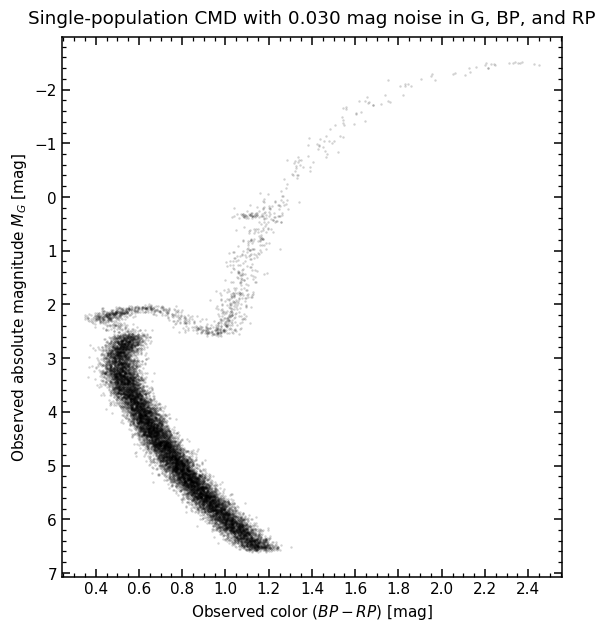

In [4]:
plot_rng = np.random.default_rng(11)
plot_idx = plot_rng.choice(n_samples, size=min(15_000, n_samples), replace=False)

fig, ax = plt.subplots(figsize=(5.6, 6.2), constrained_layout=True)

ax.scatter(
    cmd_observed[plot_idx, CMD_COLOR_COLUMN],
    cmd_observed[plot_idx, CMD_GMAG_COLUMN],
    s=3.0,
    alpha=0.18,
    color="black",
    linewidths=0,
    rasterized=True,
)

ax.set_xlabel(r"Observed color $(BP - RP)$ [mag]")
ax.set_ylabel(r"Observed absolute magnitude $M_G$ [mag]")
ax.set_title(f"Single-population CMD with {OBSERVATION_NOISE_STD:.3f} mag noise in G, BP, and RP", pad=10)
ax.invert_yaxis()
ax.grid(False)

ax.xaxis.set_major_locator(MultipleLocator(0.2))
ax.xaxis.set_minor_locator(MultipleLocator(0.05))
ax.yaxis.set_major_locator(MultipleLocator(1.0))
ax.yaxis.set_minor_locator(MultipleLocator(0.2))

ax.tick_params(which="major", length=6, width=1.1)
ax.tick_params(which="minor", length=3, width=0.9)

for spine in ax.spines.values():
    spine.set_linewidth(1.1)

plt.show()


We now train directly on the **standardized observed CMD**. Each standardized observed data point `x` is treated as a sample from the target distribution.

For each batch point `x` and Gaussian noise draw `e`, the bridge is

$$
z_t = t x + (1 - t) e.
$$

The neural network stays in pure data space and predicts a point in the same CMD coordinates:

$$
\hat{x}_\theta(z_t, t).
$$

We then convert that prediction into an induced velocity field,

$$
v_\theta(z_t, t) = \frac{\hat{x}_\theta(z_t, t) - z_t}{1 - t},
$$

and keep the same interpretable velocity target and loss:

$$
v^*(x, e) = x - e,
$$

$$
\mathcal{L}_v = \mathbb{E}\left[\|v^*(x, e) - v_\theta(z_t, t)\|^2\right].
$$

Times are sampled from a logit-normal distribution,

$$
t = \sigma\left(\mu + \sigma_t \, \xi\right), \qquad \xi \sim \mathcal{N}(0, 1),
$$

with `mu = -0.8`, `sigma_t = 0.8`, and denominator clipping near `t = 1`.


In [5]:
class FlowMLP(nn.Module):
    hidden_dim: int = 256
    output_dim: int = 2
    n_linear_layers: int = 5

    @nn.compact
    def __call__(self, z: jnp.ndarray, t: jnp.ndarray) -> jnp.ndarray:
        if self.n_linear_layers < 2:
            raise ValueError("n_linear_layers must be at least 2.")

        hidden = jnp.concatenate([z, t], axis=-1)
        for _ in range(self.n_linear_layers - 1):
            hidden = nn.Dense(
                self.hidden_dim,
                kernel_init=nn.initializers.glorot_uniform(),
                bias_init=nn.initializers.zeros_init(),
            )(hidden)
            hidden = jax.nn.relu(hidden)

        return nn.Dense(
            self.output_dim,
            kernel_init=nn.initializers.glorot_uniform(),
            bias_init=nn.initializers.zeros_init(),
        )(hidden)


def count_parameters(params) -> int:
    return sum(leaf.size for leaf in jax.tree_util.tree_leaves(params))


def make_learning_rate_schedule(
    learning_rate: float,
    train_steps: int,
    warmup_fraction: float,
):
    warmup_steps = max(1, int(train_steps * warmup_fraction))
    cosine_steps = max(train_steps - warmup_steps, 1)
    schedule = optax.warmup_cosine_decay_schedule(
        init_value=0.0,
        peak_value=learning_rate,
        warmup_steps=warmup_steps,
        decay_steps=cosine_steps,
        end_value=0.0,
    )
    return schedule, warmup_steps, cosine_steps


def build_fixed_validation_targets(
    data_array: np.ndarray,
    seed: int,
    time_mu: float,
    time_sigma: float,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    logit_t = time_mu + time_sigma * rng.standard_normal((len(data_array), 1)).astype(np.float32)
    t = (1.0 / (1.0 + np.exp(-logit_t))).astype(np.float32)
    e = rng.normal(size=data_array.shape).astype(np.float32)
    z = (t * data_array + (1.0 - t) * e).astype(np.float32)
    v_target = (data_array - e).astype(np.float32)
    return z, t, v_target


In [6]:
HIDDEN_DIM = 256
N_LINEAR_LAYERS = 4
TRAIN_STEPS = 10_000
BATCH_SIZE = 1024
LEARNING_RATE = 5.0e-3
LR_WARMUP_FRACTION = 0.10
TIME_MU = -0.8
TIME_SIGMA = 0.8
DENOM_CLIP = 0.05
VAL_BATCH_SIZE = 1024
VAL_EVERY = 256
FIXED_VAL_SEED = 123

learning_rate_schedule, warmup_steps, cosine_steps = make_learning_rate_schedule(
    learning_rate=LEARNING_RATE,
    train_steps=TRAIN_STEPS,
    warmup_fraction=LR_WARMUP_FRACTION,
)

model = FlowMLP(
    hidden_dim=HIDDEN_DIM,
    output_dim=train_array.shape[1],
    n_linear_layers=N_LINEAR_LAYERS,
)

rng = jax.random.PRNGKey(7)
rng, init_rng = jax.random.split(rng)

initial_params = model.init(
    init_rng,
    jnp.ones((1, train_array.shape[1]), dtype=jnp.float32),
    jnp.ones((1, 1), dtype=jnp.float32),
)["params"]

state = train_state.TrainState.create(
    apply_fn=model.apply,
    params=initial_params,
    tx=optax.adam(learning_rate=learning_rate_schedule),
)

val_z_fixed, val_t_fixed, val_v_target_fixed = build_fixed_validation_targets(
    val_array,
    seed=FIXED_VAL_SEED,
    time_mu=TIME_MU,
    time_sigma=TIME_SIGMA,
)


def predict_x(params, z: jnp.ndarray, t: jnp.ndarray) -> jnp.ndarray:
    return model.apply({"params": params}, z, t)


@jax.jit
def train_step(state, x, rng):
    rng_t, rng_e = jax.random.split(rng)

    def loss_fn(params) -> jax.Array:
        logit_t = TIME_MU + TIME_SIGMA * jax.random.normal(rng_t, (x.shape[0], 1), dtype=x.dtype)
        t = jax.nn.sigmoid(logit_t)

        e = jax.random.normal(rng_e, x.shape, dtype=x.dtype)
        z = t * x + (1.0 - t) * e
        raw = state.apply_fn({"params": params}, z, t)

        v_target = x - e
        v_pred = (raw - z) / jnp.clip(1.0 - t, a_min=DENOM_CLIP)
        return jnp.mean((v_target - v_pred) ** 2)

    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    return state, loss


@jax.jit
def eval_batch(params, z, t, v_target):
    raw = predict_x(params, z, t)
    v_pred = (raw - z) / jnp.clip(1.0 - t, a_min=DENOM_CLIP)
    return jnp.mean((v_target - v_pred) ** 2)


def estimate_validation_loss(
    params,
    val_z: np.ndarray,
    val_t: np.ndarray,
    val_v_target: np.ndarray,
    batch_size: int = VAL_BATCH_SIZE,
) -> float:
    losses = []
    for batch_start in range(0, len(val_z), batch_size):
        batch_stop = min(batch_start + batch_size, len(val_z))
        z_batch = jnp.asarray(val_z[batch_start:batch_stop])
        t_batch = jnp.asarray(val_t[batch_start:batch_stop])
        v_batch = jnp.asarray(val_v_target[batch_start:batch_stop])
        losses.append(float(eval_batch(params, z_batch, t_batch, v_batch)))
    return float(np.mean(losses))


### Run training

Validation is deterministic in this notebook: the bridge times and bridge noise for the validation set are sampled **once** with `FIXED_VAL_SEED = 123` and then reused for every validation call. That makes the validation curve much less noisy and easier to interpret.


In [7]:
history = {
    "step": [],
    "train_loss": [],
    "val_step": [],
    "val_loss": [],
    "lr": [],
}

batch_rng = np.random.default_rng(7)
best_val_loss = float("inf")
best_step = None
best_params = state.params

print(f"Model:                  {type(model).__name__}")
print(f"Trainable parameters:   {count_parameters(state.params):,}")
print(f"Batch size:             {BATCH_SIZE}")
print(f"Train steps:            {TRAIN_STEPS}")
print(f"Warmup steps:           {warmup_steps}")
print(f"Cosine-decay steps:     {cosine_steps}")
print(f"Validation every:       {VAL_EVERY}")
print(f"Fixed validation seed:  {FIXED_VAL_SEED}")
print(f"Time sampler:           sigmoid({TIME_MU} + {TIME_SIGMA} * N(0, 1))")
print(f"Denominator clip:       {DENOM_CLIP}")

progress = tqdm(range(1, TRAIN_STEPS + 1), desc="Training", leave=False)
for step in progress:
    batch_idx = batch_rng.integers(0, len(train_array), size=BATCH_SIZE)
    x_batch = jnp.asarray(train_array[batch_idx])

    rng, step_rng = jax.random.split(rng)
    state, loss = train_step(state, x_batch, step_rng)

    loss_value = float(loss)
    lr_value = float(learning_rate_schedule(int(state.step)))

    history["step"].append(step)
    history["train_loss"].append(loss_value)
    history["lr"].append(lr_value)

    if step == 1 or step % VAL_EVERY == 0 or step == TRAIN_STEPS:
        val_loss = estimate_validation_loss(
            state.params,
            val_z_fixed,
            val_t_fixed,
            val_v_target_fixed,
        )
        history["val_step"].append(step)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_step = step
            best_params = state.params

        progress.set_postfix(train=f"{loss_value:.4f}", val=f"{val_loss:.4f}", lr=f"{lr_value:.2e}")
    elif step % 50 == 0:
        progress.set_postfix(train=f"{loss_value:.4f}", lr=f"{lr_value:.2e}")

print()
print(f"Best validation step:   {best_step}")
print(f"Best validation loss:   {best_val_loss:.5f}")


Model:                  FlowMLP
Trainable parameters:   133,122
Batch size:             1024
Train steps:            10000
Warmup steps:           1000
Cosine-decay steps:     9000
Validation every:       256
Fixed validation seed:  123
Time sampler:           sigmoid(-0.8 + 0.8 * N(0, 1))
Denominator clip:       0.05



Best validation step:   8960
Best validation loss:   1.41700


### Summarise training

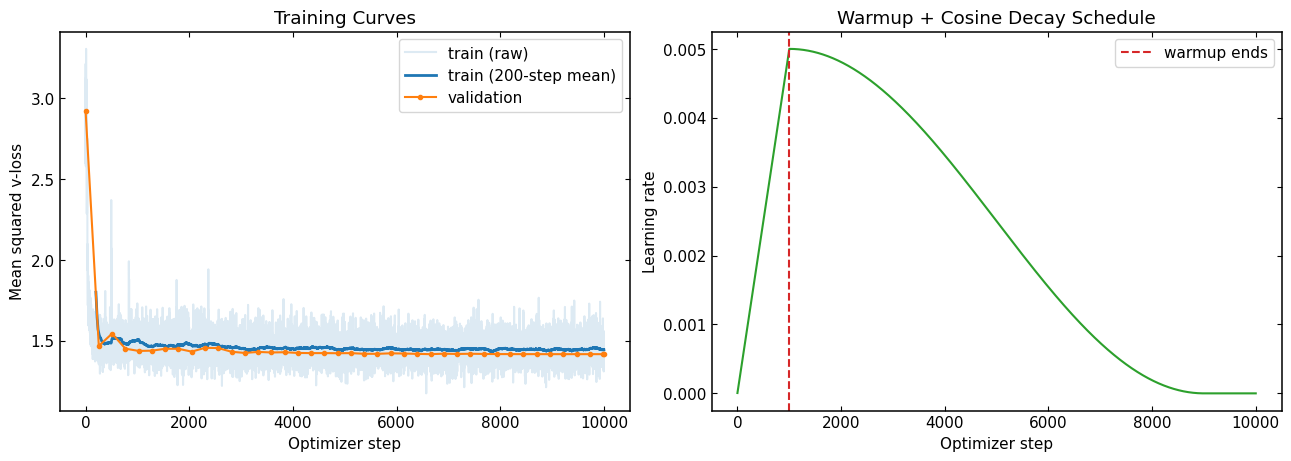

In [8]:
steps = np.asarray(history["step"])
train_losses = np.asarray(history["train_loss"])
val_steps = np.asarray(history["val_step"])
val_losses = np.asarray(history["val_loss"])
learning_rates = np.asarray(history["lr"])

smooth_window = min(200, len(train_losses))
if smooth_window > 1:
    smooth_kernel = np.ones(smooth_window, dtype=np.float64) / smooth_window
    train_losses_smooth = np.convolve(train_losses, smooth_kernel, mode="valid")
    smooth_steps = steps[smooth_window - 1 :]
else:
    train_losses_smooth = train_losses
    smooth_steps = steps

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.5), constrained_layout=True)

axes[0].plot(steps, train_losses, color="tab:blue", alpha=0.15, label="train (raw)")
axes[0].plot(
    smooth_steps,
    train_losses_smooth,
    color="tab:blue",
    linewidth=2,
    label=f"train ({smooth_window}-step mean)",
)
axes[0].plot(val_steps, val_losses, color="tab:orange", marker="o", markersize=3, label="validation")
axes[0].set_xlabel("Optimizer step")
axes[0].set_ylabel("Mean squared v-loss")
axes[0].set_title("Training Curves")
axes[0].legend()

axes[1].plot(steps, learning_rates, color="tab:green")
axes[1].axvline(warmup_steps, color="tab:red", linestyle="--", linewidth=1.5, label="warmup ends")
axes[1].set_xlabel("Optimizer step")
axes[1].set_ylabel("Learning rate")
axes[1].set_title("Warmup + Cosine Decay Schedule")
axes[1].legend()

plt.show()


## Visual validation

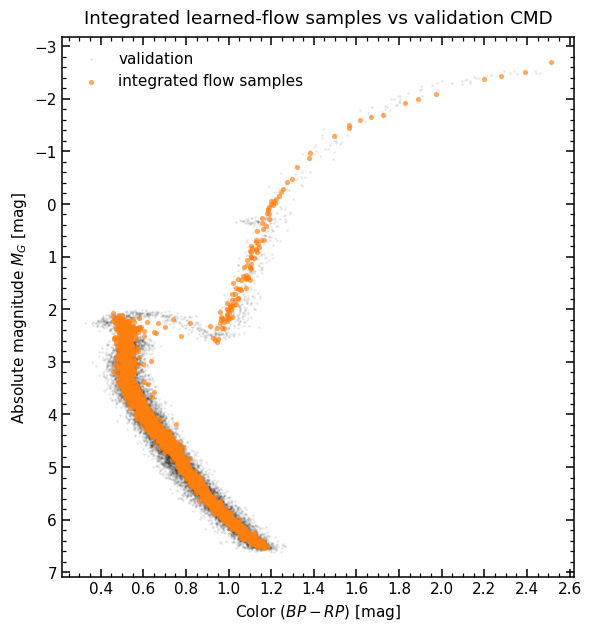

In [9]:
SAMPLE_COUNT = 3_000
INTEGRATION_STEPS = 300
SAMPLING_SEED = 321


@jax.jit
def predict_velocity(params, z, t):
    raw = predict_x(params, z, t)
    return (raw - z) / jnp.clip(1.0 - t, a_min=DENOM_CLIP)


def integrate_learned_flow(params, x0, n_steps=INTEGRATION_STEPS):
    z = jnp.asarray(x0, dtype=jnp.float32)
    dt = np.float32(1.0 / n_steps)

    for step in range(n_steps):
        t_value = np.float32(step / n_steps)
        t_batch = jnp.full((z.shape[0], 1), t_value, dtype=z.dtype)
        z = z + dt * predict_velocity(params, z, t_batch)

    return np.asarray(z, dtype=np.float32)


sample_rng = np.random.default_rng(SAMPLING_SEED)
x0_samples = sample_rng.normal(size=(SAMPLE_COUNT, train_array.shape[1])).astype(np.float32)
params_for_sampling = best_params if best_step is not None else state.params

generated_standardized = integrate_learned_flow(params_for_sampling, x0_samples)
generated_cmd = (generated_standardized * standardization_std + standardization_mean).astype(np.float32)

val_plot_rng = np.random.default_rng(22)
val_plot_idx = val_plot_rng.choice(len(x_val), size=min(12_000, len(x_val)), replace=False)
val_plot = x_val[val_plot_idx]

fig, ax = plt.subplots(figsize=(5.8, 6.2), constrained_layout=True)

ax.scatter(
    val_plot[:, CMD_COLOR_COLUMN],
    val_plot[:, CMD_GMAG_COLUMN],
    s=3.0,
    alpha=0.10,
    color="black",
    linewidths=0,
    rasterized=True,
    label="validation",
)
ax.scatter(
    generated_cmd[:, CMD_COLOR_COLUMN],
    generated_cmd[:, CMD_GMAG_COLUMN],
    s=14,
    alpha=0.65,
    color="tab:orange",
    linewidths=0,
    label="integrated flow samples",
)

ax.set_xlabel(r"Color $(BP - RP)$ [mag]")
ax.set_ylabel(r"Absolute magnitude $M_G$ [mag]")
ax.set_title("Integrated learned-flow samples vs validation CMD", pad=10)
ax.invert_yaxis()
ax.grid(False)
ax.legend(loc="upper left", frameon=False)

ax.xaxis.set_major_locator(MultipleLocator(0.2))
ax.xaxis.set_minor_locator(MultipleLocator(0.05))
ax.yaxis.set_major_locator(MultipleLocator(1.0))
ax.yaxis.set_minor_locator(MultipleLocator(0.2))

ax.tick_params(which="major", length=6, width=1.1)
ax.tick_params(which="minor", length=3, width=0.9)

for spine in ax.spines.values():
    spine.set_linewidth(1.1)

plt.show()
